In [18]:
# 1. 라이브러리 & 전처리 데이터 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2단계에서 저장한 데이터 불러오기
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()

X_val = pd.read_csv('data/processed/X_val.csv')
y_val = pd.read_csv('data/processed/y_val.csv').squeeze()

X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

print("=== 데이터 로딩 완료 ===")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val: {y_val.shape}")

=== 데이터 로딩 완료 ===
X_train: (235700, 41), y_train: (235700,)
X_val:   (18896, 41), y_val: (18896,)


In [19]:
# 2. 클래스 매핑 정의
class_names = {0: 'DoS', 1: 'Normal', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
print(class_names)

{0: 'DoS', 1: 'Normal', 2: 'Probe', 3: 'R2L', 4: 'U2R'}


In [20]:
# 3. 베이스라인 모델 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

print("=== Logistic Regression 결과 ===")
print(classification_report(y_val, y_pred_lr, target_names=class_names.values()))

=== Logistic Regression 결과 ===
              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      6889
      Normal       0.99      0.89      0.94     10101
       Probe       0.75      0.94      0.84      1749
         R2L       0.28      0.95      0.44       149
         U2R       0.03      0.75      0.05         8

    accuracy                           0.93     18896
   macro avg       0.61      0.91      0.65     18896
weighted avg       0.96      0.93      0.94     18896



In [21]:
# 4. 베이스라인 모델 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

print("=== Decision Tree 결과 ===")
print(classification_report(y_val, y_pred_dt, target_names=class_names.values()))

=== Decision Tree 결과 ===
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      6889
      Normal       1.00      1.00      1.00     10101
       Probe       0.99      1.00      0.99      1749
         R2L       0.93      0.95      0.94       149
         U2R       0.33      0.38      0.35         8

    accuracy                           1.00     18896
   macro avg       0.85      0.86      0.86     18896
weighted avg       1.00      1.00      1.00     18896



In [22]:
# 5. 메인 모델: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # 사용 가능한 모든 코어를 사용 (가장 빠름)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("=== Random Forest 결과 ===")
print(classification_report(y_val, y_pred_rf, target_names=class_names.values()))

=== Random Forest 결과 ===
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      6889
      Normal       1.00      1.00      1.00     10101
       Probe       1.00      1.00      1.00      1749
         R2L       0.99      0.96      0.97       149
         U2R       0.86      0.75      0.80         8

    accuracy                           1.00     18896
   macro avg       0.97      0.94      0.95     18896
weighted avg       1.00      1.00      1.00     18896



In [23]:
# 6. 메인 모델: XGBoost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)

print("=== XGBoost 결과 ===")
print(classification_report(y_val, y_pred_xgb, target_names=class_names.values()))

=== XGBoost 결과 ===
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      6889
      Normal       1.00      1.00      1.00     10101
       Probe       1.00      1.00      1.00      1749
         R2L       1.00      0.98      0.99       149
         U2R       0.73      1.00      0.84         8

    accuracy                           1.00     18896
   macro avg       0.95      1.00      0.97     18896
weighted avg       1.00      1.00      1.00     18896



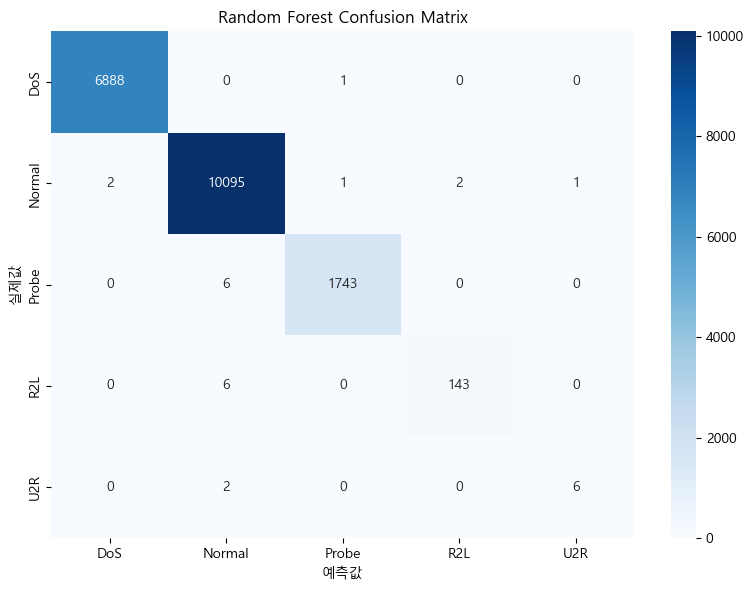

In [24]:
# 7. Confusion Matrix 시각화 (Random Forest)
cm = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names.values(),
    yticklabels=class_names.values()
)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

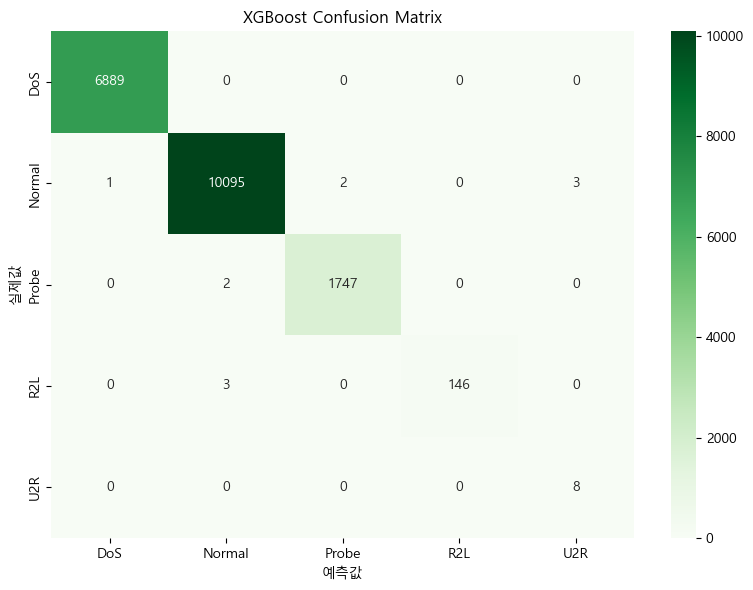

In [25]:
# 8.XGBoost Confusion Matrix 확인
cm_xgb = confusion_matrix(y_val, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_names.values(),
    yticklabels=class_names.values()
)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

In [26]:
# 9. 5-Fold Cross Validation (XGBoost)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv=5, scoring='f1_macro', n_jobs=-1
)

print("=== 5-Fold Cross Validation (F1-macro) ===")
print(f"각 Fold 점수: {cv_scores}")
print(f"평균: {cv_scores.mean():.4f}")
print(f"표준편차: {cv_scores.std():.4f}")

=== 5-Fold Cross Validation (F1-macro) ===
각 Fold 점수: [0.99949091 0.9995969  0.99978786 0.99963934 0.99976662]
평균: 0.9997
표준편차: 0.0001


In [27]:
# 10. 최종 모델 Test 평가
y_pred_test = xgb_model.predict(X_test)

print("=== XGBoost 최종 Test 평가 ===")
print(classification_report(y_test, y_pred_test, target_names=class_names.values()))

=== XGBoost 최종 Test 평가 ===
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      6889
      Normal       1.00      1.00      1.00     10102
       Probe       1.00      1.00      1.00      1748
         R2L       0.99      0.97      0.98       149
         U2R       0.70      0.88      0.78         8

    accuracy                           1.00     18896
   macro avg       0.94      0.97      0.95     18896
weighted avg       1.00      1.00      1.00     18896



In [28]:
# 11. 모델 저장
import pickle

with open('models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print(">>> 모델 저장 완료 <<<")

>>> 모델 저장 완료 <<<
